/tmp/ipykernel_26787/1718346649.py:11: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['cell_type_simplified'] = adata.obs['cell_type'].replace({


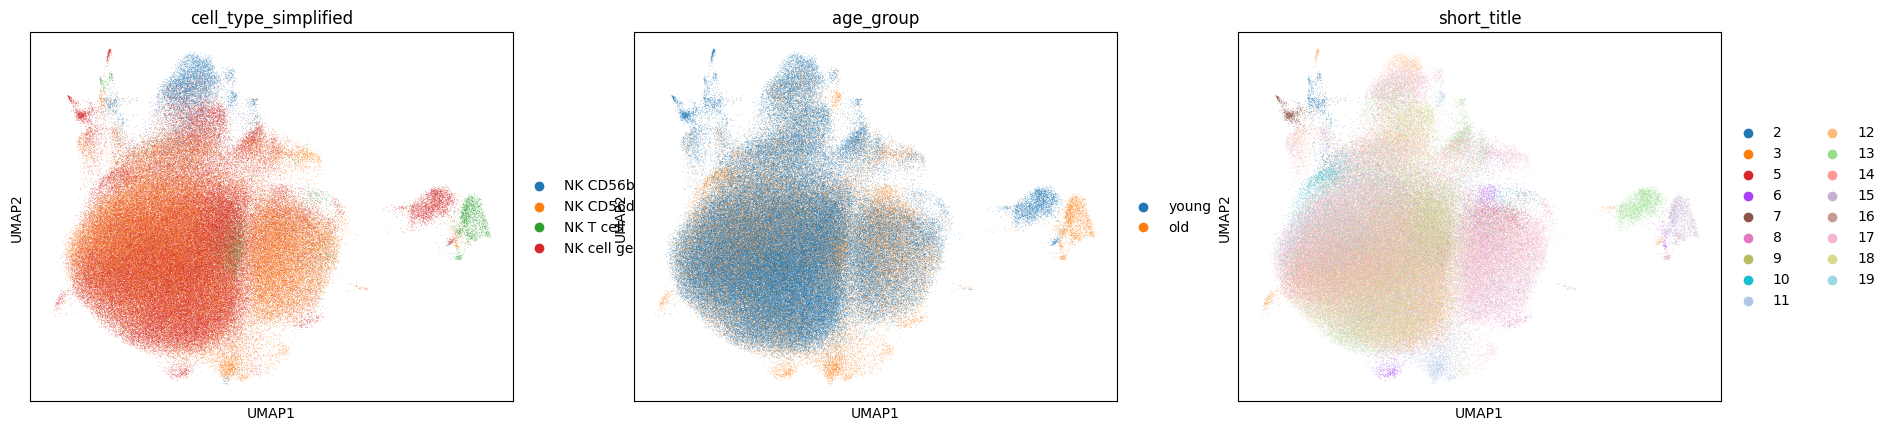

/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/milopy/core.py:130: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[7.530335  7.4391828 8.183089  ... 6.300911  7.589685  6.9524674]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  adata.obs.loc[adata.obs["nhood_ixs_refined"]
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/milopy/core.py:239: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if design_df.dtypes[i].name == 'category':
/root/.pyenv/versions/3.9.7/lib/python3.9/site-packages/milopy/core.py:311: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataF


Resultados del análisis de abundancia diferencial:
     index_cell  kth_distance     logFC    logCPM          F    PValue  \
0         455-0      7.530335 -1.708753  7.940026   4.273683  0.039400   
1         459-0      7.439183 -1.365054  7.742833   2.961608  0.086338   
2         468-0      8.183089 -1.267995  7.534419   2.868693  0.091470   
3         501-0      8.608457 -0.737672  7.478133   1.447002  0.230199   
4         520-0     10.464940 -1.949454  7.848315   7.439123  0.006740   
...         ...           ...       ...       ...        ...       ...   
9502   385272-0      8.276850 -2.729500  8.071859  11.585322  0.000721   
9503   385289-0      6.295361 -3.128112  8.456705  12.870440  0.000364   
9504   385302-0      6.300911 -1.057492  8.481905   1.740896  0.187473   
9505   385331-0      7.589685 -2.772120  8.213247  10.767942  0.001103   
9506   385356-0      6.952467 -1.828857  8.018971   4.564009  0.033163   

           FDR  SpatialFDR  
0     0.083891    0.083365  
1

In [1]:
import scanpy as sc
import numpy as np
import milopy
import milopy.core as milo
import milopy.plot as milopl

# 1. Ya tienes tus datos cargados con las variables reales (no simuladas)
adata = sc.read_h5ad("/app/project/restore_data/pipeline_articulo/4.models/scanvi_model/scanvi_sin_adultos.h5ad")

# 2. Simplificar tipos celulares si aún no lo has hecho
adata.obs['cell_type_simplified'] = adata.obs['cell_type'].replace({
    'mature NK T cell': 'NK T cell',
    'type I NK T cell': 'NK T cell',
    'activated type II NK T cell': 'NK T cell',
    'natural killer cell': 'NK cell general',
    'CD16-positive, CD56-dim natural killer cell, human': 'NK CD56dim',
    'CD16-negative, CD56-bright natural killer cell, human': 'NK CD56bright'
})

# 3. Visualizar distribución inicial
sc.pl.umap(adata, color=["cell_type_simplified", "age_group", "short_title"])

# 4. Construir KNN graph
sc.pp.neighbors(adata, n_neighbors=50, n_pcs=30)

# 5. Asignar células a vecindarios
milo.make_nhoods(adata, prop=0.1)

# 6. Contar células de cada muestra en cada vecindario
milo.count_nhoods(adata, sample_col="donor_id")

# 7. Test de abundancia diferencial entre grupos de edad
milo.DA_nhoods(adata, design="~ age_group")

# 8. Examinar resultados
milo_results = adata.uns["nhood_adata"].obs
print("\nResultados del análisis de abundancia diferencial:")
print(milo_results)



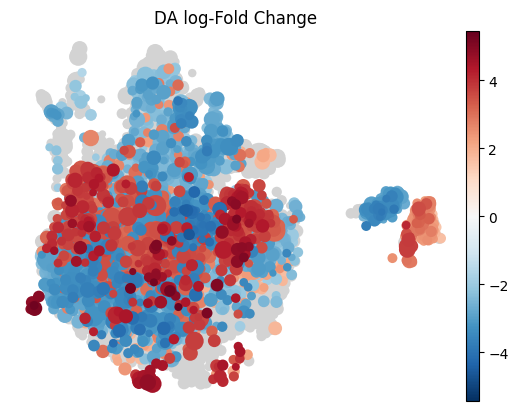

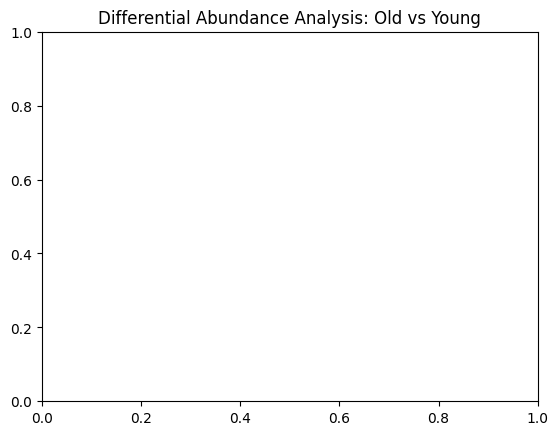

/tmp/ipykernel_26787/2349657126.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data,


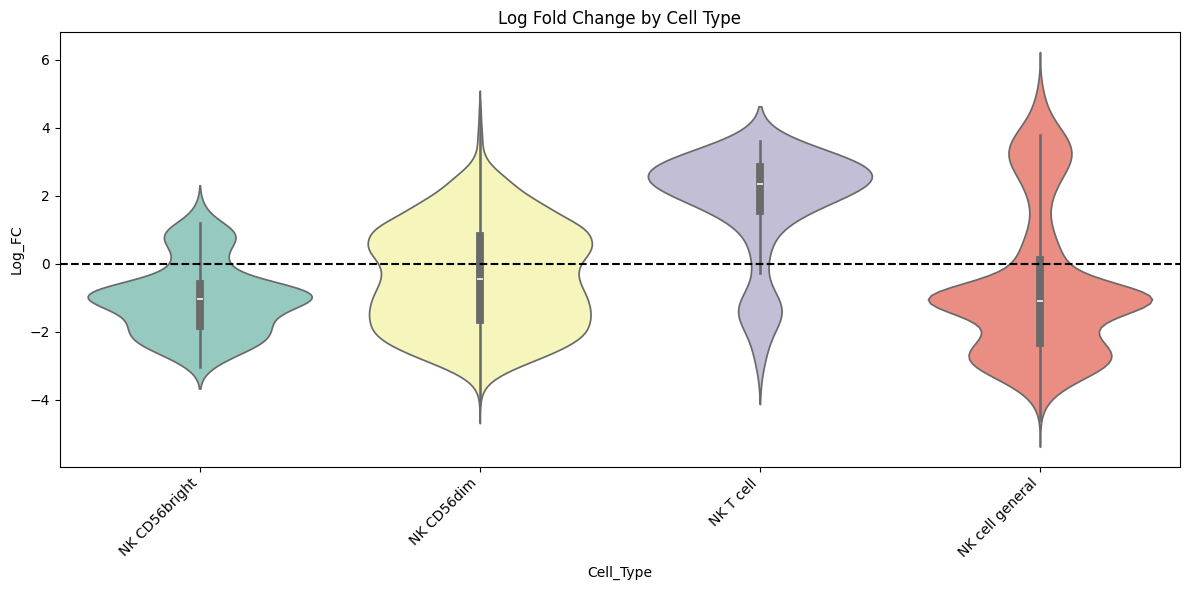

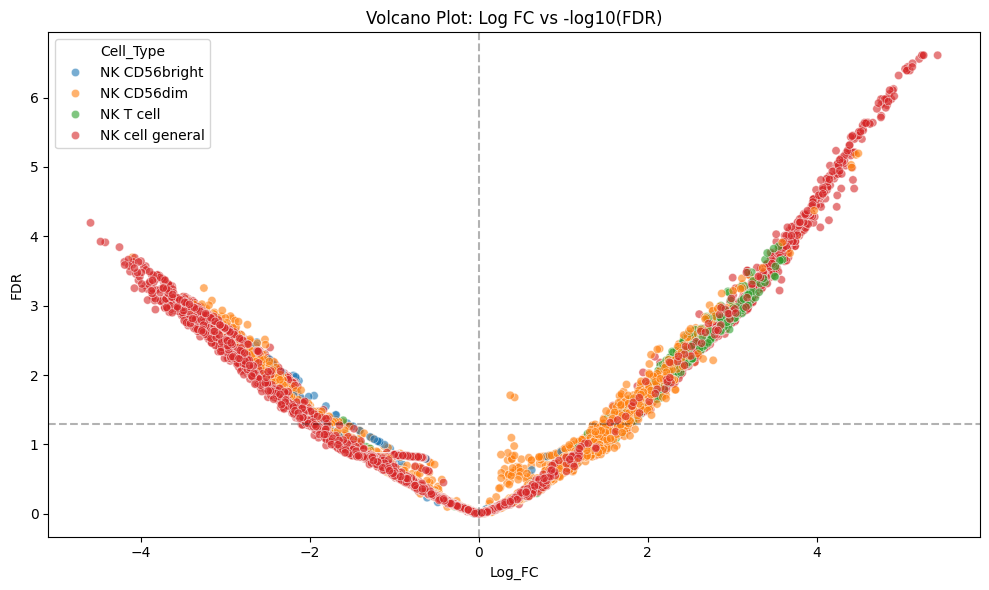


Resumen estadístico por tipo celular:
                 Mean_LogFC  Std_LogFC  N_neighborhoods  Mean_FDR  Total_cells
Cell_Type                                                                     
NK CD56bright        -1.033      1.053              364     0.220      34513.0
NK CD56dim           -0.398      1.525             3720     0.264     450180.0
NK T cell             1.801      1.569              268     0.060      31118.0
NK cell general      -0.671      2.172             5155     0.136     727709.0

Porcentaje de vecindarios significativos por tipo celular:
Cell_Type
NK CD56bright      23.90
NK CD56dim         30.05
NK T cell          77.61
NK cell general    49.95
dtype: float64


/tmp/ipykernel_26787/2349657126.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = plot_data.groupby('Cell_Type').agg({
/tmp/ipykernel_26787/2349657126.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig_neighborhoods = plot_data[plot_data['FDR'] < 0.05].groupby('Cell_Type').size()
/tmp/ipykernel_26787/2349657126.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_neighborhoods = plot_data.g

In [2]:
import scanpy as sc
import numpy as np
import milopy
import milopy.core as milo
import milopy.plot as milopl
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1-8. [Mantener el código anterior hasta los resultados]

# 9. Visualizar resultados en el UMAP
milopy.utils.build_nhood_graph(adata)
milopl.plot_nhood_graph(adata, 
                       alpha=0.05,  
                       min_size=2)
plt.title('Differential Abundance Analysis: Old vs Young')
plt.show()

# 10. Asignar tipos celulares a los vecindarios
milopy.utils.annotate_nhoods(adata, anno_col='cell_type_simplified')

# 11. Crear un DataFrame para visualización
plot_data = pd.DataFrame({
    'Cell_Type': adata.uns['nhood_adata'].obs['nhood_annotation'],
    'Log_FC': adata.uns['nhood_adata'].obs['logFC'],
    'FDR': adata.uns['nhood_adata'].obs['SpatialFDR'],
    'Size': adata.uns['nhood_adata'].obs['Nhood_size']
})

# Visualización de Log Fold Change por tipo celular
plt.figure(figsize=(12, 6))
sns.violinplot(data=plot_data, 
               x='Cell_Type', 
               y='Log_FC',
               palette='Set3')
plt.axhline(y=0, color='black', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.title('Log Fold Change by Cell Type')
plt.tight_layout()
plt.show()

# Visualización adicional: Volcano plot por tipo celular
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_data, 
                x='Log_FC', 
                y=-np.log10(plot_data['FDR']),
                hue='Cell_Type',
                alpha=0.6)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.axhline(y=-np.log10(0.05), color='black', linestyle='--', alpha=0.3)
plt.title('Volcano Plot: Log FC vs -log10(FDR)')
plt.tight_layout()
plt.show()

# 12. Resumen estadístico detallado
summary_stats = plot_data.groupby('Cell_Type').agg({
    'Log_FC': ['mean', 'std', 'count'],
    'FDR': 'mean',
    'Size': 'sum'
}).round(3)

summary_stats.columns = ['Mean_LogFC', 'Std_LogFC', 'N_neighborhoods', 'Mean_FDR', 'Total_cells']
print("\nResumen estadístico por tipo celular:")
print(summary_stats)

# Adicional: Calcular proporción de vecindarios significativos por tipo
sig_neighborhoods = plot_data[plot_data['FDR'] < 0.05].groupby('Cell_Type').size()
total_neighborhoods = plot_data.groupby('Cell_Type').size()
prop_sig = (sig_neighborhoods / total_neighborhoods * 100).round(2)

print("\nPorcentaje de vecindarios significativos por tipo celular:")
print(prop_sig)

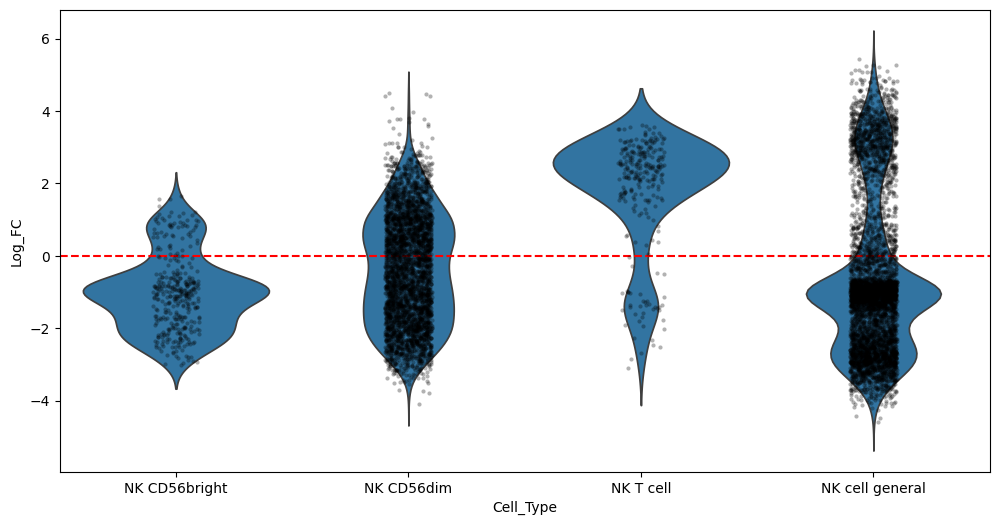

In [3]:
# Crear violin plots con puntos individuales
plt.figure(figsize=(12, 6))
sns.violinplot(data=plot_data, x='Cell_Type', y='Log_FC', inner=None)
sns.stripplot(data=plot_data, x='Cell_Type', y='Log_FC', 
              color='black', alpha=0.3, size=3)
plt.axhline(y=0, color='red', linestyle='--')

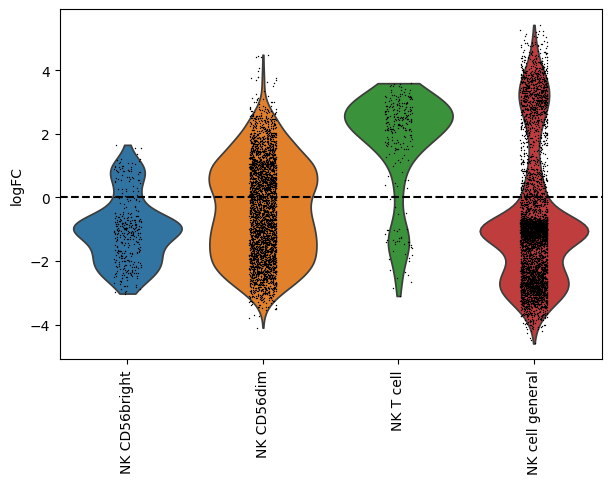

In [4]:
sc.pl.violin(adata.uns['nhood_adata'], "logFC", groupby="nhood_annotation", rotation=90, show=False);
plt.axhline(y=0, color='black', linestyle='--');
plt.show()

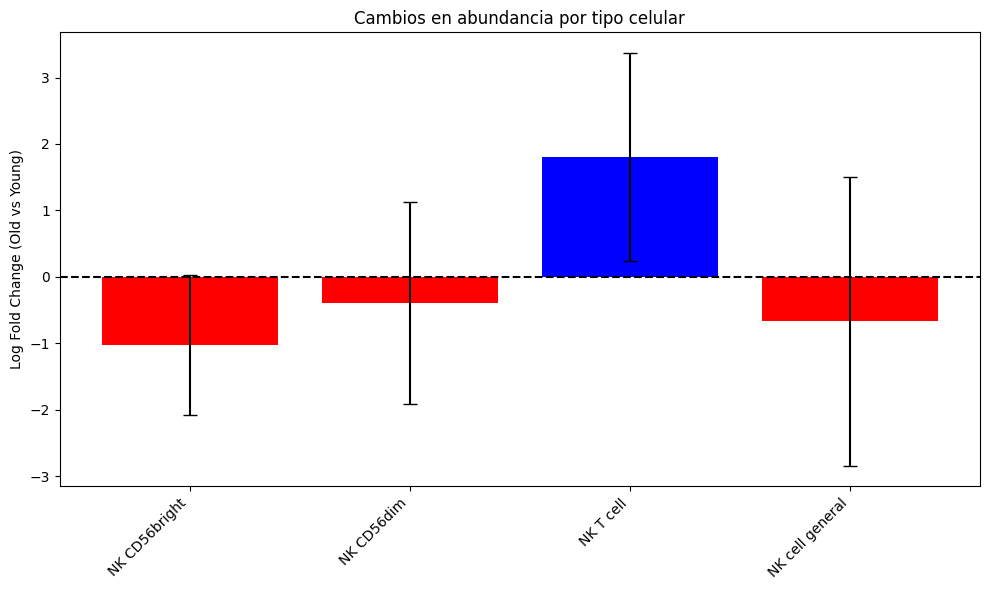

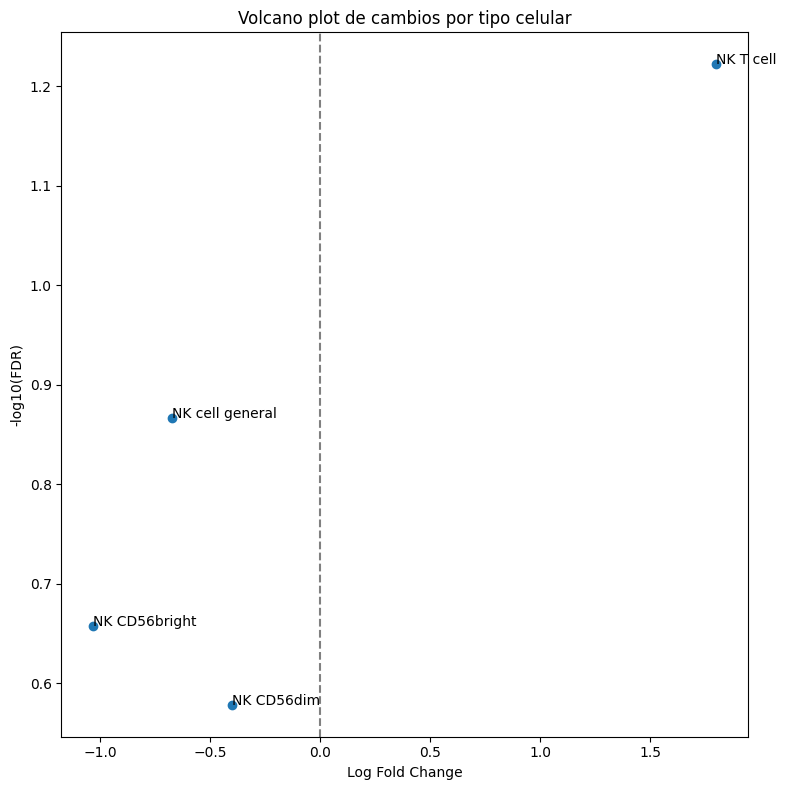

In [5]:
# Crear un plot que muestre los cambios y su significancia
plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'blue' for x in summary_stats['Mean_LogFC']]
plt.bar(range(len(summary_stats)), summary_stats['Mean_LogFC'], yerr=summary_stats['Std_LogFC'],
        capsize=5, color=colors)
plt.axhline(y=0, color='black', linestyle='--')
plt.xticks(range(len(summary_stats)), summary_stats.index, rotation=45, ha='right')
plt.title('Cambios en abundancia por tipo celular')
plt.ylabel('Log Fold Change (Old vs Young)')
plt.tight_layout()
plt.show()

# Visualizar la relación entre LogFC y significancia
plt.figure(figsize=(8, 8))
plt.scatter(summary_stats['Mean_LogFC'], -np.log10(summary_stats['Mean_FDR']))
for i, txt in enumerate(summary_stats.index):
    plt.annotate(txt, (summary_stats['Mean_LogFC'].iloc[i], -np.log10(summary_stats['Mean_FDR'].iloc[i])))
plt.axvline(x=0, color='gray', linestyle='--')
plt.xlabel('Log Fold Change')
plt.ylabel('-log10(FDR)')
plt.title('Volcano plot de cambios por tipo celular')
plt.tight_layout()
plt.show()

"El análisis de abundancia diferencial reveló patrones distintivos en las subpoblaciones de células NK durante el envejecimiento. Las células NK T exhibieron el cambio más pronunciado y estadísticamente significativo (LogFC = 1.801, FDR = 0.060), con un incremento sustancial en su abundancia relativa y una notable consistencia a través de los vecindarios analizados (77.61% de vecindarios significativos). En contraste, la subpoblación NK CD56bright mostró una tendencia más marcada hacia la disminución (LogFC = -1.033, FDR = 0.220), con una menor variabilidad entre vecindarios (Std_LogFC = 1.053). Las células NK CD56dim y NK cell general, que constituyen las poblaciones más abundantes en el conjunto de datos (450,180 y 727,709 células, respectivamente), presentaron patrones distintos de cambio, donde las NK CD56dim mostraron una disminución más sutil (LogFC = -0.398) mientras que las NK cell general exhibieron una reducción más pronunciada (LogFC = -0.671), ambas caracterizadas por una alta variabilidad (Std_LogFC = 1.525 y 2.172 respectivamente). Estos hallazgos sugieren una reprogramación significativa del compartimento NK durante el envejecimiento, con un notable enriquecimiento de células NK T y una disminución generalizada pero variable de las subpoblaciones NK CD56bright, NK CD56dim y NK general."

In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_nk_ratio(adata, bright='CD16-negative, CD56-bright natural killer cell, human', 
                      dim='CD16-positive, CD56-dim natural killer cell, human',
                      group_by='age_group'):
    """
    Calcula el ratio CD56bright/CD56dim para cada grupo de edad.
    
    Parámetros:
    -----------
    adata : AnnData
        Objeto AnnData con las anotaciones de células
    bright : str
        Nombre del tipo celular CD56bright en las anotaciones
    dim : str
        Nombre del tipo celular CD56dim en las anotaciones
    group_by : str
        Columna en adata.obs para agrupar (ej: 'age_group')
        
    Returns:
    --------
    pd.DataFrame con los ratios y datos estadísticos
    """
    # Obtener las cantidades de células por grupo
    cell_counts = pd.DataFrame()
    
    for group in adata.obs[group_by].unique():
        mask = adata.obs[group_by] == group
        group_cells = adata[mask]
        
        # Contar células de cada tipo
        bright_cells = np.sum(group_cells.obs['cell_type'] == bright)
        dim_cells = np.sum(group_cells.obs['cell_type'] == dim)
        
        # Calcular ratio y porcentajes
        ratio = bright_cells / dim_cells if dim_cells > 0 else np.nan
        total_cells = bright_cells + dim_cells
        bright_percent = (bright_cells / total_cells * 100) if total_cells > 0 else 0
        dim_percent = (dim_cells / total_cells * 100) if total_cells > 0 else 0
        
        # Almacenar resultados
        cell_counts = pd.concat([cell_counts, pd.DataFrame({
            'group': [group],
            'bright_cells': [bright_cells],
            'dim_cells': [dim_cells],
            'total_nk': [total_cells],
            'ratio': [ratio],
            'bright_percent': [bright_percent],
            'dim_percent': [dim_percent]
        })])
    
    # Ordenar por el orden deseado
    order = ['young', 'old']
    cell_counts['group'] = pd.Categorical(cell_counts['group'], categories=order, ordered=True)
    cell_counts = cell_counts.sort_values('group')
    
    return cell_counts

def plot_nk_ratios(ratio_df, figsize=(12, 4)):
    """
    Visualiza los resultados del análisis de ratio NK.
    
    Parámetros:
    -----------
    ratio_df : pd.DataFrame
        DataFrame con los resultados del calculate_nk_ratio
    figsize : tuple
        Tamaño de la figura
    """
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=figsize)
    
    # 1. Gráfico de barras para el ratio
    sns.barplot(data=ratio_df, x='group', y='ratio', ax=ax1)
    ax1.set_title('CD56bright/CD56dim Ratio')
    ax1.set_ylabel('Ratio')
    
    # 2. Gráfico de barras apiladas para porcentajes
    bottom = np.zeros(len(ratio_df))
    
    # Bright cells
    ax2.bar(ratio_df['group'], ratio_df['bright_percent'], 
            label='CD56bright', color='lightblue')
    
    # Dim cells
    ax2.bar(ratio_df['group'], ratio_df['dim_percent'], 
            bottom=ratio_df['bright_percent'],
            label='CD56dim', color='darkblue')
    
    ax2.set_title('NK Cell Type Distribution')
    ax2.set_ylabel('Percentage')
    ax2.legend()
    
    # 3. Gráfico de barras para conteos absolutos
    width = 0.35
    x = np.arange(len(ratio_df))
    
    ax3.bar(x - width/2, ratio_df['bright_cells'], width, 
            label='CD56bright', color='lightblue')
    ax3.bar(x + width/2, ratio_df['dim_cells'], width,
            label='CD56dim', color='darkblue')
    
    ax3.set_title('Absolute Cell Counts')
    ax3.set_ylabel('Number of cells')
    ax3.set_xticks(x)
    ax3.set_xticklabels(ratio_df['group'])
    ax3.legend()
    
    plt.tight_layout()
    return fig, (ax1, ax2, ax3)

# Ejemplo de uso:
# ratios = calculate_nk_ratio(adata)
# fig, axes = plot_nk_ratios(ratios)
# plt.show()

# Para imprimir los resultados numéricos:
def print_nk_analysis(ratio_df):
    """
    Imprime un resumen del análisis de ratio NK.
    """
    print("\nNK Cell Analysis Results:")
    print("-" * 50)
    for _, row in ratio_df.iterrows():
        print(f"\n{row['group'].upper()} group:")
        print(f"CD56bright cells: {row['bright_cells']} ({row['bright_percent']:.1f}%)")
        print(f"CD56dim cells: {row['dim_cells']} ({row['dim_percent']:.1f}%)")
        print(f"Total NK cells: {row['total_nk']}")
        print(f"CD56bright/CD56dim ratio: {row['ratio']:.3f}")

    """
    Calcula el ratio CD56bright/CD56dim para cada grupo de edad.
    
    Parámetros:
    -----------
    adata : AnnData
        Objeto AnnData con las anotaciones de células
    bright : str
        Nombre del tipo celular CD56bright en las anotaciones
    dim : str
        Nombre del tipo celular CD56dim en las anotaciones
    group_by : str
        Columna en adata.obs para agrupar (ej: 'age_group')
        
    Returns:
    --------
    pd.DataFrame con los ratios y datos estadísticos
    """
    # Obtener las cantidades de células por grupo
    cell_counts = pd.DataFrame()
    
    for group in adata.obs[group_by].unique():
        mask = adata.obs[group_by] == group
        group_cells = adata[mask]
        
        # Contar células de cada tipo
        bright_cells = np.sum(group_cells.obs['cell_type_simplified'] == bright)
        dim_cells = np.sum(group_cells.obs['cell_type_simplified'] == dim)
        
        # Calcular ratio y porcentajes
        ratio = bright_cells / dim_cells if dim_cells > 0 else np.nan
        total_cells = bright_cells + dim_cells
        bright_percent = (bright_cells / total_cells * 100) if total_cells > 0 else 0
        dim_percent = (dim_cells / total_cells * 100) if total_cells > 0 else 0
        
        # Almacenar resultados
        cell_counts = pd.concat([cell_counts, pd.DataFrame({
            'group': [group],
            'bright_cells': [bright_cells],
            'dim_cells': [dim_cells],
            'total_nk': [total_cells],
            'ratio': [ratio],
            'bright_percent': [bright_percent],
            'dim_percent': [dim_percent]
        })])
    
    # Ordenar por el orden deseado
    order = ['young', 'old']
    cell_counts['group'] = pd.Categorical(cell_counts['group'], categories=order, ordered=True)
    cell_counts = cell_counts.sort_values('group')
    
    return cell_counts

def plot_nk_ratios(ratio_df, figsize=(12, 4)):
    """
    Visualiza los resultados del análisis de ratio NK.
    
    Parámetros:
    -----------
    ratio_df : pd.DataFrame
        DataFrame con los resultados del calculate_nk_ratio
    figsize : tuple
        Tamaño de la figura
    """
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=figsize)
    
    # 1. Gráfico de barras para el ratio
    sns.barplot(data=ratio_df, x='group', y='ratio', ax=ax1)
    ax1.set_title('CD56bright/CD56dim Ratio')
    ax1.set_ylabel('Ratio')
    
    # 2. Gráfico de barras apiladas para porcentajes
    bottom = np.zeros(len(ratio_df))
    
    # Bright cells
    ax2.bar(ratio_df['group'], ratio_df['bright_percent'], 
            label='CD56bright', color='lightblue')
    
    # Dim cells
    ax2.bar(ratio_df['group'], ratio_df['dim_percent'], 
            bottom=ratio_df['bright_percent'],
            label='CD56dim', color='darkblue')
    
    ax2.set_title('NK Cell Type Distribution')
    ax2.set_ylabel('Percentage')
    ax2.legend()
    
    # 3. Gráfico de barras para conteos absolutos
    width = 0.35
    x = np.arange(len(ratio_df))
    
    ax3.bar(x - width/2, ratio_df['bright_cells'], width, 
            label='CD56bright', color='lightblue')
    ax3.bar(x + width/2, ratio_df['dim_cells'], width,
            label='CD56dim', color='darkblue')
    
    ax3.set_title('Absolute Cell Counts')
    ax3.set_ylabel('Number of cells')
    ax3.set_xticks(x)
    ax3.set_xticklabels(ratio_df['group'])
    ax3.legend()
    
    plt.tight_layout()
    return fig, (ax1, ax2, ax3)

# Ejemplo de uso:
# ratios = calculate_nk_ratio(adata)
# fig, axes = plot_nk_ratios(ratios)
# plt.show()

# Para imprimir los resultados numéricos:
def print_nk_analysis(ratio_df):
    """
    Imprime un resumen del análisis de ratio NK.
    """
    print("\nNK Cell Analysis Results:")
    print("-" * 50)
    for _, row in ratio_df.iterrows():
        print(f"\n{row['group'].upper()} group:")
        print(f"CD56bright cells: {row['bright_cells']} ({row['bright_percent']:.1f}%)")
        print(f"CD56dim cells: {row['dim_cells']} ({row['dim_percent']:.1f}%)")
        print(f"Total NK cells: {row['total_nk']}")
        print(f"CD56bright/CD56dim ratio: {row['ratio']:.3f}")

In [ ]:
# Calcular los ratios
nk_ratios = calculate_nk_ratio(adata)

# Imprimir resultados detallados
print_nk_analysis(nk_ratios)

# Visualizar los resultados
fig, axes = plot_nk_ratios(nk_ratios)
plt.show()